### 🔹 **Célula 1 — Importação**

In [1]:
import pandas as pd

# Configuração de exibição
pd.set_option('display.max_columns', None)

### 🔹 **Célula 2 — Carregamento dos dados**

In [2]:
df = pd.read_csv('../data/raw/vendas_2023_2024.csv')

df.head()

,id,id_client,id_product,qtd,total,sale_date
0,0,42,105,11,3405.0,2023-09-10
1,1,3,136,9,16873.9,15-09-2024
2,2,25,139,7,9475.3,2024-08-13
3,4,20,23,5,55893.0,2023-02-03
4,5,8,57,4,451403.9,2024-02-12


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9895 entries, 0 to 9894
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   id          9895 non-null   int64         
 1   id_client   9895 non-null   int64         
 2   id_product  9895 non-null   int64         
 3   qtd         9895 non-null   int64         
 4   total       9895 non-null   float64       
 5   sale_date   4913 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(4)
memory usage: 464.0 KB


### **🔹 Célula 3 — Estrutura do dataset**

In [3]:
num_linhas, num_colunas = df.shape

print(f"Total de Linhas: {num_linhas}")
print(f"Colunas: {num_colunas}")

Total de Linhas: 9895
Colunas: 6


### **🔹 Célula 4 — Datas**

In [6]:
df['sale_date'] = pd.to_datetime(df['sale_date'], errors='coerce')

data_min = df['sale_date'].min()
data_max = df['sale_date'].max()

# Formatação para DD/MM/AAAA
data_min_fmt = data_min.strftime('%d/%m/%Y')
data_max_fmt = data_max.strftime('%d/%m/%Y')

print(f"Data mínima: {data_min_fmt}")
print(f"Data máxima: {data_max_fmt}")

Data mínima: 01/01/2023
Data máxima: 31/12/2024


### 🔹 **Célula 5 - Estatística da Coluna Total**

In [13]:
def formatar_brl(valor):
    return f"R$ {valor:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")

print(f"Mínimo: {formatar_brl(valor_min)}")
print(f"Máximo: {formatar_brl(valor_max)}")
print(f"Médio: {formatar_brl(valor_medio)}")

Mínimo: R$ 294,50
Máximo: R$ 2.222.973,00
Médio: R$ 263.797,83


### **🔹 Célula 6 — Verificação de qualidade**

In [10]:
# Valores nulos
print(df.isnull().sum())

# Estatísticas gerais
df.describe()

id               0
id_client        0
id_product       0
qtd              0
total            0
sale_date     4982
dtype: int64


,id,id_client,id_product,qtd,total,sale_date
count,9895.000000,9895.000000,9895.000000,9895.000000,9.895000e+03,4913
mean,5000.755533,24.874583,75.255786,8.015260,2.637978e+05,2023-12-30 02:38:51.610014208
min,0.000000,1.000000,1.000000,1.000000,2.945000e+02,2023-01-01 00:00:00
25%,2501.500000,13.000000,37.000000,4.000000,2.313820e+04,2023-06-30 00:00:00
50%,4999.000000,25.000000,74.000000,8.000000,8.222500e+04,2023-12-26 00:00:00
75%,7505.500000,37.000000,114.000000,12.000000,3.390945e+05,2024-06-30 00:00:00
max,9999.000000,49.000000,150.000000,15.000000,2.222973e+06,2024-12-31 00:00:00
std,2887.000000,14.177715,43.533397,4.301723,3.900072e+05,NaN


### **🔹 Célula 7 — Detecção de possíveis outliers**

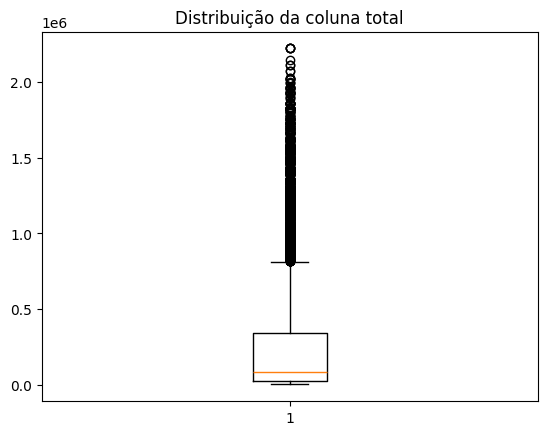

In [11]:
import matplotlib.pyplot as plt

plt.boxplot(df['total'])
plt.title('Distribuição da coluna total')
plt.show()